# 01 — Import & Exploration des données UMTS

**Objectif** : Charger le fichier `data.csv`, faire une EDA complète et vérifier le format multi-valeurs.

**Données** : Mesures KPI radio UMTS — qualité signal (RSCP, Ec/N0), codes de brouillage, canaux actifs.

In [1]:
# ── Cellule optionnelle d'installation ────────────────────────────────────────
RUN_INSTALL = False
if RUN_INSTALL:
    import subprocess, sys
    pkgs = ["pandas", "numpy", "matplotlib", "seaborn", "scipy"]
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet"] + pkgs)

## 1. Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 60)
sns.set_theme(style="whitegrid", palette="muted")

print(f"pandas  : {pd.__version__}")
print(f"numpy   : {np.__version__}")
print("Imports OK")

pandas  : 3.0.2
numpy   : 2.4.4
✅ Imports OK


## 2. Chemins & Chargement

In [3]:
# Chemin relatif au notebook — fonctionne partout (Windows/Linux/Mac)
NOTEBOOK_DIR = Path().resolve()
DATA_DIR     = NOTEBOOK_DIR / "data"
DATA_FILE    = DATA_DIR / "data.csv"

print(f"Répertoire notebook : {NOTEBOOK_DIR}")
print(f"Fichier données     : {DATA_FILE}")
print(f"Fichier existe      : {DATA_FILE.exists()}")

Répertoire notebook : C:\projet ingeneurie des réseaux\notebooks
Fichier données     : C:\projet ingeneurie des réseaux\notebooks\data\data.csv
Fichier existe      : True


In [4]:
# Chargement robuste : toutes les colonnes en str pour préserver les multi-valeurs
df_raw = pd.read_csv(
    DATA_FILE,
    sep=";",
    dtype=str,          # IMPORTANT : ne pas laisser pandas convertir
    na_values=["", "n/a", "N/A", "NA", "nan", "NaN", "null"],
    keep_default_na=True,
    encoding="utf-8",
    encoding_errors="replace",
)

# Strip des espaces dans les noms de colonnes
df_raw.columns = df_raw.columns.str.strip()

print(f"Shape brut : {df_raw.shape}")
print(f"Colonnes   : {list(df_raw.columns)}")

Shape brut : (8332, 8)
Colonnes   : ['Time', 'Band (active)', 'Channel number (active)', 'Scrambling code (active)', 'RSCP (active)', 'Ec/N0 (active)', 'RSCP (detected)', 'Scrambling code (detected)']


## 3. EDA de base

In [5]:
print("=" * 55)
print(f"  Lignes   : {df_raw.shape[0]:,}")
print(f"  Colonnes : {df_raw.shape[1]}")
print("=" * 55)
df_raw.head(10)

  Lignes   : 8,332
  Colonnes : 8


,Time,Band (active),Channel number (active),Scrambling code (active),RSCP (active),Ec/N0 (active),RSCP (detected),Scrambling code (detected)
0,8:36:11.915,UMTS FDD 2100 band 1,10738,387,-73.2,-9.9,NaN,NaN
1,8:36:12.338,UMTS FDD 2100 band 1,10738,387,-78.1,-14.3,NaN,NaN
2,8:36:13.021,UMTS FDD 2100 band 1,10738,387,-74.3,-10.6,NaN,NaN
3,8:36:13.535,"UMTS FDD 2100 band 1, UMTS FDD 2100 band 1","10713, 10738","387, 387","-68.1, -71.9","-7.0, -7.2","-70.4, -80.4","395, 138"
4,8:36:14.018,"UMTS FDD 2100 band 1, UMTS FDD 2100 band 1","10738, 10713","387, 387","-71.4, -69.1","-5.9, -8.2","-70.0, -79.8","395, 138"
5,8:36:14.540,"UMTS FDD 2100 band 1, UMTS FDD 2100 band 1","10738, 10713","387, 387","-75.1, -70.5","-7.5, -7.7","-71.9, -81.9","395, 138"
6,8:36:15.094,"UMTS FDD 2100 band 1, UMTS FDD 2100 band 1","10738, 10713","387, 387","-73.5, -70.3","-6.9, -7.8","-71.0, -80.2","395, 138"
7,8:36:15.634,"UMTS FDD 2100 band 1, UMTS FDD 2100 band 1","10738, 10713","387, 387","-72.5, -69.7","-5.1, -7.4","-70.8, -80.1","395, 138"
8,8:36:16.134,"UMTS FDD 2100 band 1, UMTS FDD 2100 band 1","10738, 10713","387, 387","-72.4, -70.1","-4.9, -8.8","-70.5, -80.8","395, 138"
9,8:36:16.305,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Types (tous string par construction)
print("\n── Types ──")
print(df_raw.dtypes)


── Types ──
Time                          str
Band (active)                 str
Channel number (active)       str
Scrambling code (active)      str
RSCP (active)                 str
Ec/N0 (active)                str
RSCP (detected)               str
Scrambling code (detected)    str
dtype: object


In [7]:
# Valeurs manquantes
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({"Missing": missing, "Missing_%": missing_pct})
missing_df = missing_df[missing_df["Missing"] > 0].sort_values("Missing_%", ascending=False)

print("\n── Valeurs manquantes ──")
if missing_df.empty:
    print("Aucune valeur manquante détectée dans le brut.")
else:
    print(missing_df.to_string())


── Valeurs manquantes ──
                            Missing  Missing_%
Scrambling code (detected)     1215      14.58
RSCP (detected)                1215      14.58
Band (active)                    10       0.12
Scrambling code (active)         10       0.12
Channel number (active)          10       0.12
Ec/N0 (active)                   10       0.12
RSCP (active)                    10       0.12


In [8]:
# Doublons
n_dup = df_raw.duplicated().sum()
print(f"\n── Doublons exacts : {n_dup} ({n_dup/len(df_raw)*100:.2f}%) ──")


── Doublons exacts : 24 (0.29%) ──


In [9]:
# Statistiques descriptives des colonnes string (cardinalités)
print("\n── Cardinalités (nb valeurs uniques par colonne) ──")
for col in df_raw.columns:
    n_unique = df_raw[col].nunique(dropna=True)
    top_val  = df_raw[col].mode(dropna=True).iloc[0] if n_unique > 0 else "N/A"
    print(f"  {col:<40} nunique={n_unique:>6}   mode='{str(top_val)[:30]}'")


── Cardinalités (nb valeurs uniques par colonne) ──
  Time                                     nunique=  8299   mode=' 8:52:33.070'
  Band (active)                            nunique=    17   mode='UMTS FDD 2100 band 1, UMTS FDD'
  Channel number (active)                  nunique=    55   mode='10688, 10713'
  Scrambling code (active)                 nunique=   718   mode='125, 125'
  RSCP (active)                            nunique=  6941   mode='-67.0'
  Ec/N0 (active)                           nunique=  4691   mode='-3.0'
  RSCP (detected)                          nunique=  5844   mode='-108.4, -116.7'
  Scrambling code (detected)               nunique=  3231   mode='49'


## 4. Vérification du format multi-valeurs

Certaines cellules contiennent plusieurs mesures séparées par des virgules (ex: `-68.1, -71.9`). On quantifie ici le phénomène.

In [10]:
def count_values_in_cell(series: pd.Series) -> pd.Series:
    """Compte le nombre de sous-valeurs séparées par virgule dans chaque cellule."""
    return series.dropna().apply(lambda x: len(str(x).split(",")))

# Colonnes susceptibles de contenir des multi-valeurs
multi_cols = [
    "Channel number (active)",
    "Scrambling code (active)",
    "RSCP (active)",
    "Ec/N0 (active)",
    "RSCP (detected)",
    "Scrambling code (detected)",
]

# Ne garder que celles présentes
multi_cols = [c for c in multi_cols if c in df_raw.columns]

print("\n── Distribution du nombre de valeurs par cellule ──")
multi_stats = {}
for col in multi_cols:
    counts = count_values_in_cell(df_raw[col])
    dist   = counts.value_counts().sort_index()
    multi_stats[col] = dist
    max_n  = counts.max() if len(counts) else 0
    pct_multi = (counts > 1).mean() * 100
    print(f"\n  [{col}]  max={max_n}  cellules_multi={pct_multi:.1f}%")
    print(dist.rename("nb_lignes").to_string())


── Distribution du nombre de valeurs par cellule ──

  [Channel number (active)]  max=5  cellules_multi=85.6%
Channel number (active)
1    1197
2    4493
3    1956
4     631
5      45

  [Scrambling code (active)]  max=5  cellules_multi=85.6%
Scrambling code (active)
1    1197
2    4493
3    1956
4     631
5      45

  [RSCP (active)]  max=5  cellules_multi=85.6%
RSCP (active)
1    1197
2    4493
3    1956
4     631
5      45

  [Ec/N0 (active)]  max=5  cellules_multi=85.6%
Ec/N0 (active)
1    1197
2    4493
3    1956
4     631
5      45

  [RSCP (detected)]  max=35  cellules_multi=82.4%
RSCP (detected)
1     1251
2      968
3      941
4      786
5      540
6      368
7      253
8      282
9      242
10     145
11     188
12     114
13      93
14      66
15      75
16      57
17      73
18      94
19      90
20      76
21      78
22      60
23      39
24      45
25      30
26      42
27      24
28      21
29      30
30      21
31       6
32       5
33       2
34       2
35      10

  

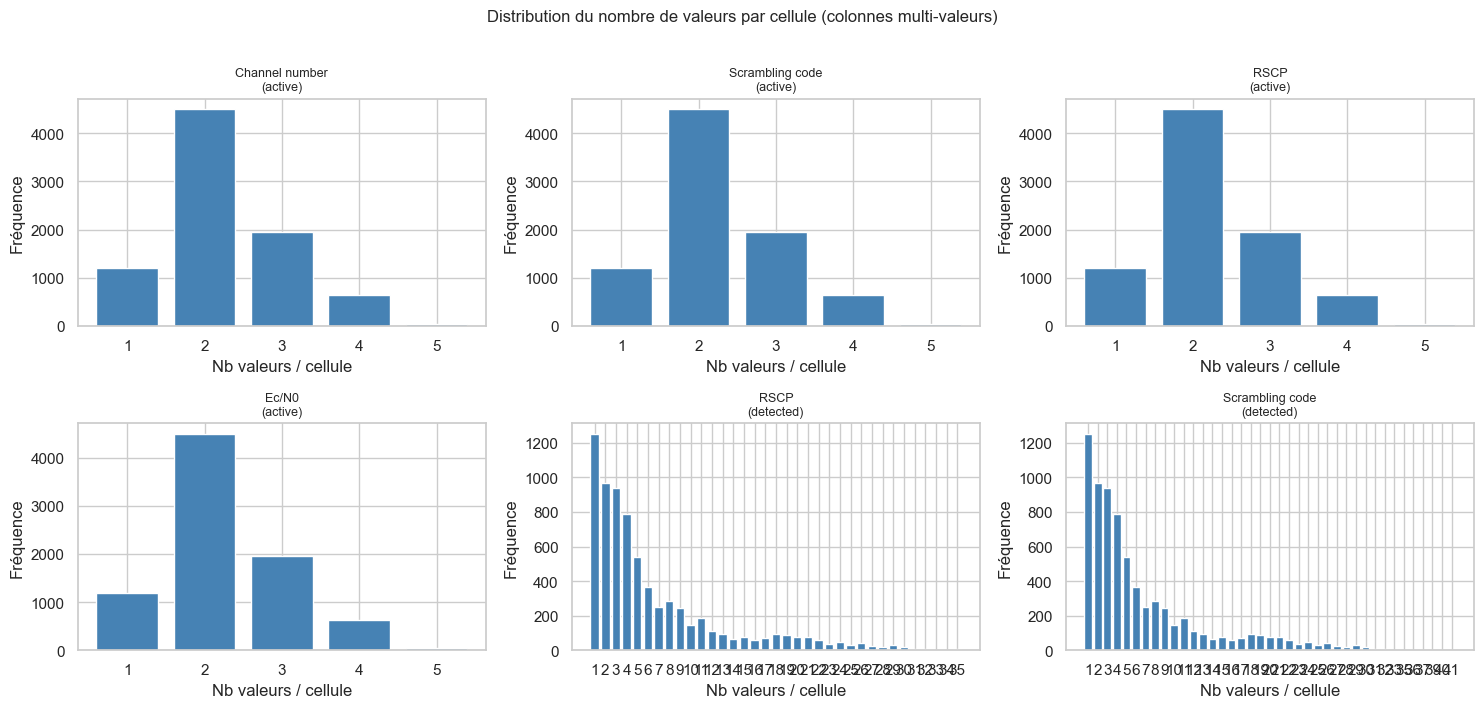

✅ Graphique multi-valeurs affiché


In [ ]:
# Visualisation : distribution du nombre de valeurs par colonne
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes = axes.flatten()

for i, col in enumerate(multi_cols):
    ax = axes[i]
    counts = count_values_in_cell(df_raw[col])
    dist   = counts.value_counts().sort_index()
    ax.bar(dist.index.astype(str), dist.values, color="steelblue", edgecolor="white")
    ax.set_title(col.replace(" (", "\n("), fontsize=9)
    ax.set_xlabel("Nb valeurs / cellule")
    ax.set_ylabel("Fréquence")

# Masquer les axes inutilisés
for j in range(len(multi_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribution du nombre de valeurs par cellule (colonnes multi-valeurs)", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()
print("Graphique multi-valeurs affiché")

In [12]:
# Exemples concrets de lignes avec multi-valeurs
print("\n── Exemples de cellules multi-valeurs ──")
for col in multi_cols[:3]:
    mask = df_raw[col].dropna().apply(lambda x: "," in str(x))
    examples = df_raw[col].dropna()[mask].head(5)
    print(f"\n  {col}:")
    for v in examples.values:
        print(f"    '{v}'")


── Exemples de cellules multi-valeurs ──

  Channel number (active):
    '10713, 10738'
    '10738, 10713'
    '10738, 10713'
    '10738, 10713'
    '10738, 10713'

  Scrambling code (active):
    '387, 387'
    '387, 387'
    '387, 387'
    '387, 387'
    '387, 387'

  RSCP (active):
    '-68.1, -71.9'
    '-71.4, -69.1'
    '-75.1, -70.5'
    '-73.5, -70.3'
    '-72.5, -69.7'


## 5. Aperçu colonne `Time` et `Band`

In [13]:
if "Time" in df_raw.columns:
    print("── Aperçu colonne Time ──")
    print(df_raw["Time"].head(10).to_string())
    # Tentative de conversion datetime
    try:
        t_parsed = pd.to_datetime(df_raw["Time"], infer_datetime_format=True, errors="coerce")
        pct_ok = t_parsed.notna().mean() * 100
        print(f"  -> Conversion datetime : {pct_ok:.1f}% réussi")
        if pct_ok > 50:
            print(f"  Plage temporelle : {t_parsed.min()} → {t_parsed.max()}")
    except Exception as e:
        print(f"  -> Impossible de parser comme datetime : {e}")

if "Band (active)" in df_raw.columns:
    print("\n── Distribution Band (active) ──")
    print(df_raw["Band (active)"].value_counts(dropna=False).to_string())

── Aperçu colonne Time ──
0     8:36:11.915
1     8:36:12.338
2     8:36:13.021
3     8:36:13.535
4     8:36:14.018
5     8:36:14.540
6     8:36:15.094
7     8:36:15.634
8     8:36:16.134
9     8:36:16.305
  -> Impossible de parser comme datetime : to_datetime() got an unexpected keyword argument 'infer_datetime_format'

── Distribution Band (active) ──
Band (active)
UMTS FDD 2100 band 1, UMTS FDD 2100 band 1                                                                      4057
UMTS FDD 2100 band 1, UMTS FDD 2100 band 1, UMTS FDD 2100 band 1                                                1614
UMTS FDD 900 band 8                                                                                              977
UMTS FDD 2100 band 1, UMTS FDD 2100 band 1, UMTS FDD 2100 band 1, UMTS FDD 2100 band 1                           621
UMTS FDD 900 band 8, UMTS FDD 900 band 8                                                                         436
UMTS FDD 900 band 8, UMTS FDD 900 band 8, UMT

## 6. Visualisation valeurs manquantes globale

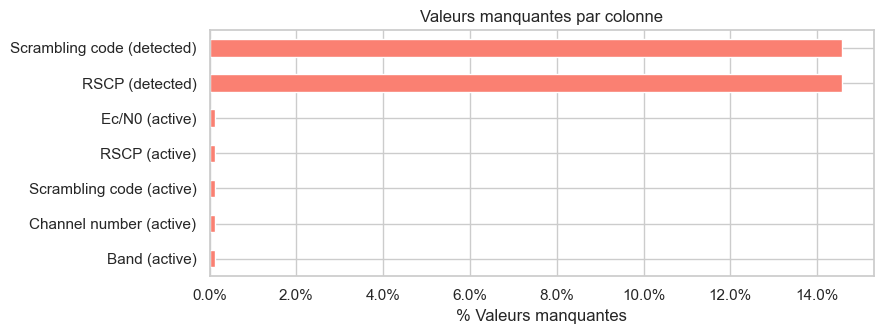

In [14]:
miss_pct = df_raw.isnull().mean() * 100
miss_pct = miss_pct[miss_pct > 0].sort_values(ascending=True)

if not miss_pct.empty:
    fig, ax = plt.subplots(figsize=(9, max(3, len(miss_pct) * 0.5)))
    miss_pct.plot(kind="barh", ax=ax, color="salmon", edgecolor="white")
    ax.set_xlabel("% Valeurs manquantes")
    ax.set_title("Valeurs manquantes par colonne")
    ax.xaxis.set_major_formatter(mticker.PercentFormatter())
    plt.tight_layout()
    plt.show()
else:
    print("Pas de valeurs manquantes à visualiser.")

## 7. Checks de validation

In [ ]:
# ── Assertions de validation ──────────────────────────────────────────────────
assert DATA_FILE.exists(), f"Fichier introuvable : {DATA_FILE}"
assert df_raw.shape[0] > 0, "DataFrame vide"
assert df_raw.shape[1] >= 5, f"Trop peu de colonnes : {df_raw.shape[1]}"
assert df_raw.dtypes.nunique() >= 1, "Problème de types"

# Vérifie qu'au moins une colonne contient des multi-valeurs
found_multi = False
for col in multi_cols:
    if df_raw[col].dropna().apply(lambda x: "," in str(x)).any():
        found_multi = True
        break

if found_multi:
    print("Multi-valeurs détectées (attendu)")
else:
    print("Aucune multi-valeur détectée — vérifier le fichier source")

print(f"Toutes assertions passées — {df_raw.shape[0]:,} lignes × {df_raw.shape[1]} colonnes")
print("\nProchaine étape : 02_feature_engineering_multivaleurs.ipynb")

✅ Multi-valeurs détectées (attendu)
✅ Toutes assertions passées — 8,332 lignes × 8 colonnes

📌 Prochaine étape : 02_feature_engineering_multivaleurs.ipynb
